In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
df = pd.read_csv('C:/Users/Karanpreet singh/OneDrive/Desktop/influenceguard_ai/data/raw.csv')
df.head(10)

,username,followers,post_frequency,likes,comments,shares,platform,verified,engagement_rate,is_fake
0,user_0,122958,25,9557.102926,263.539282,296.559281,Instagram,0,0.082282,0
1,user_1,147867,22,20854.261200,1242.450210,416.688465,Instagram,0,0.152254,0
2,user_2,132932,27,7246.132322,215.189759,73.046381,Instagram,0,0.056678,0
3,user_3,366838,27,22357.587496,789.884638,379.257726,Instagram,0,0.064134,0
4,user_4,260178,17,23198.254671,1781.585994,340.611660,Instagram,0,0.097320,0
5,user_5,120879,13,7548.138749,404.662780,211.071546,Instagram,0,0.067538,0
6,user_6,111268,1,16205.246184,1054.050312,558.924224,Instagram,0,0.160138,0
7,user_7,208892,2,27113.958548,1450.023168,502.242709,Instagram,1,0.139145,0
8,user_8,55886,9,4241.650447,225.447186,201.742582,Instagram,0,0.083542,0
9,user_9,138337,3,15058.732637,386.243159,154.612302,Instagram,0,0.112765,0


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   username         3000 non-null   object 
 1   followers        3000 non-null   int64  
 2   post_frequency   3000 non-null   int64  
 3   likes            2910 non-null   float64
 4   comments         3000 non-null   float64
 5   shares           3000 non-null   float64
 6   platform         3000 non-null   object 
 7   verified         3000 non-null   int64  
 8   engagement_rate  3000 non-null   float64
 9   is_fake          3000 non-null   int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 234.5+ KB


In [83]:
df.isnull().sum()

username            0
followers           0
post_frequency      0
likes              90
comments            0
shares              0
platform            0
verified            0
engagement_rate     0
is_fake             0
dtype: int64

In [84]:
df[df.duplicated()]

,username,followers,post_frequency,likes,comments,shares,platform,verified,engagement_rate,is_fake


In [85]:
df["likes"] = pd.to_numeric(df["likes"], errors="coerce")

Handling missing values

In [86]:
df['likes']=df['likes'].fillna(0)

Datatype conversion

In [87]:
df["likes"] = df["likes"].astype(int)
df["comments"] = df["comments"].astype(int)
df["shares"] = df["shares"].astype(int)

In [88]:
df.head(5)

,username,followers,post_frequency,likes,comments,shares,platform,verified,engagement_rate,is_fake
0,user_0,122958,25,9557,263,296,Instagram,0,0.082282,0
1,user_1,147867,22,20854,1242,416,Instagram,0,0.152254,0
2,user_2,132932,27,7246,215,73,Instagram,0,0.056678,0
3,user_3,366838,27,22357,789,379,Instagram,0,0.064134,0
4,user_4,260178,17,23198,1781,340,Instagram,0,0.097320,0


In [89]:
df.isnull().sum()

username           0
followers          0
post_frequency     0
likes              0
comments           0
shares             0
platform           0
verified           0
engagement_rate    0
is_fake            0
dtype: int64

In [90]:
df.head(10)

,username,followers,post_frequency,likes,comments,shares,platform,verified,engagement_rate,is_fake
0,user_0,122958,25,9557,263,296,Instagram,0,0.082282,0
1,user_1,147867,22,20854,1242,416,Instagram,0,0.152254,0
2,user_2,132932,27,7246,215,73,Instagram,0,0.056678,0
3,user_3,366838,27,22357,789,379,Instagram,0,0.064134,0
4,user_4,260178,17,23198,1781,340,Instagram,0,0.097320,0
5,user_5,120879,13,7548,404,211,Instagram,0,0.067538,0
6,user_6,111268,1,16205,1054,558,Instagram,0,0.160138,0
7,user_7,208892,2,27113,1450,502,Instagram,1,0.139145,0
8,user_8,55886,9,4241,225,201,Instagram,0,0.083542,0
9,user_9,138337,3,15058,386,154,Instagram,0,0.112765,0


Check for outliers

In [92]:
cols = ["followers", "likes", "comments", "shares"]

for col in cols:
    print(col)
    print("95%:", df[col].quantile(0.95))
    print("99%:", df[col].quantile(0.99))
    print("Max:", df[col].max())
    print("-"*30)

followers
95%: 473791.0
99%: 492234.8
Max: 499863
------------------------------
likes
95%: 43760.89999999999
99%: 59759.399999999965
Max: 73605
------------------------------
comments
95%: 2216.5999999999967
99%: 3673.0099999999998
Max: 5091
------------------------------
shares
95%: 2371.4499999999975
99%: 37360.149999999594
Max: 172159
------------------------------


shares have outliers in it.
so remove it

In [93]:
upper = df["shares"].quantile(0.99)
df["shares"] = df["shares"].clip(upper=upper)


In [94]:
upper = df["shares"].quantile(0.95)
df["shares"] = df["shares"].clip(upper=upper)

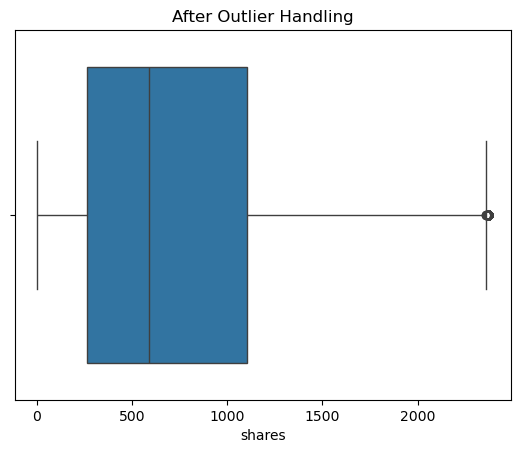

In [95]:
sns.boxplot(x=df["shares"])
plt.title("After Outlier Handling")
plt.show()

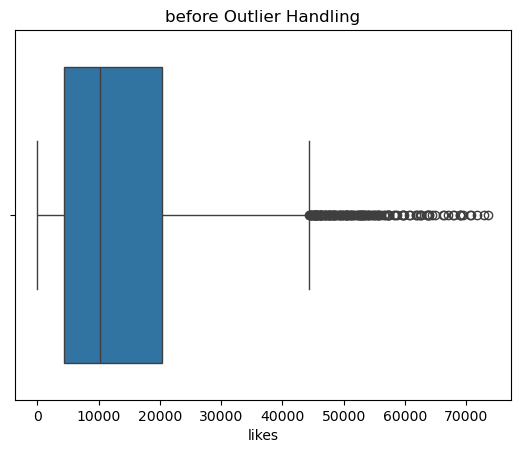

In [96]:
sns.boxplot(x=df["likes"])
plt.title("before Outlier Handling")
plt.show()

In [97]:
upper = df["likes"].quantile(0.95)
df["likes"] = df["likes"].clip(upper=upper)

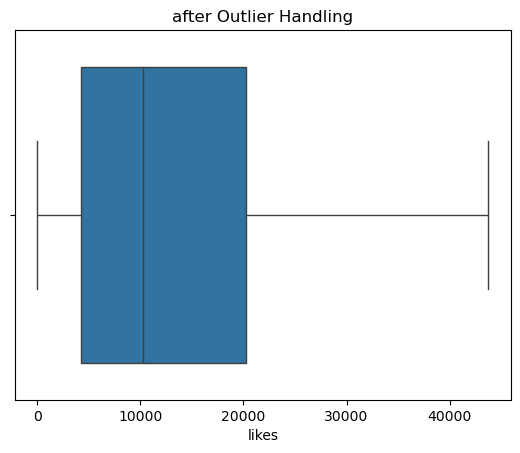

In [98]:
sns.boxplot(x=df["likes"])
plt.title("after Outlier Handling")
plt.show()

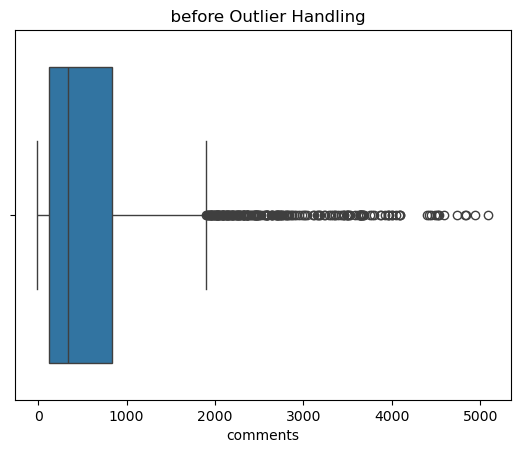

In [99]:
sns.boxplot(x=df["comments"])
plt.title("  before Outlier Handling")
plt.show()

In [100]:
upper = df["comments"].quantile(0.95)
df["comments"] = df["comments"].clip(upper=upper)

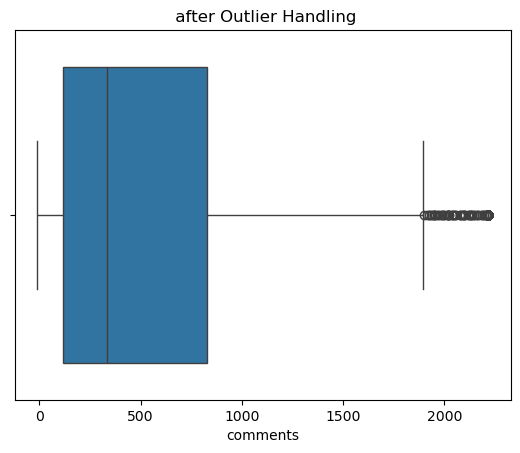

In [101]:
sns.boxplot(x=df["comments"])
plt.title(" after Outlier Handling")
plt.show()

In [102]:
cols = ["followers", "likes", "comments", "shares"]

for col in cols:
    print(col)
    print("95%:", df[col].quantile(0.95))
    print("99%:", df[col].quantile(0.99))
    print("Max:", df[col].max())
    print("-"*30)

followers
95%: 473791.0
99%: 492234.8
Max: 499863
------------------------------
likes
95%: 43758.145
99%: 43760.89999999999
Max: 43760.89999999999
------------------------------
comments
95%: 2216.0299999999997
99%: 2216.5999999999967
Max: 2216.5999999999967
------------------------------
shares
95%: 2371.0224999999996
99%: 2371.4499999999975
Max: 2371.4499999999975
------------------------------


In [103]:
df.head(20)

,username,followers,post_frequency,likes,comments,shares,platform,verified,engagement_rate,is_fake
0,user_0,122958,25,9557.0,263.0,296.00,Instagram,0,0.082282,0
1,user_1,147867,22,20854.0,1242.0,416.00,Instagram,0,0.152254,0
2,user_2,132932,27,7246.0,215.0,73.00,Instagram,0,0.056678,0
3,user_3,366838,27,22357.0,789.0,379.00,Instagram,0,0.064134,0
4,user_4,260178,17,23198.0,1781.0,340.00,Instagram,0,0.097320,0
5,user_5,120879,13,7548.0,404.0,211.00,Instagram,0,0.067538,0
6,user_6,111268,1,16205.0,1054.0,558.00,Instagram,0,0.160138,0
7,user_7,208892,2,27113.0,1450.0,502.00,Instagram,1,0.139145,0
8,user_8,55886,9,4241.0,225.0,201.00,Instagram,0,0.083542,0
9,user_9,138337,3,15058.0,386.0,154.00,Instagram,0,0.112765,0


In [105]:
cols = ["likes", "comments", "shares"]

df[cols] = df[cols].astype(int)

In [107]:
df.dtypes

username            object
followers            int64
post_frequency       int64
likes                int32
comments             int32
shares               int32
platform            object
verified             int64
engagement_rate    float64
is_fake              int64
dtype: object

In [108]:
df = df[df["followers"] > 0]

In [109]:
df["engagement_rate"] = df["engagement_rate"].round(4)

In [110]:
df["platform"].unique()

array(['Instagram', 'Twitter', 'Facebook'], dtype=object)

In [111]:
import os

base_path = r"C:/Users/Karanpreet singh/OneDrive/Desktop/influenceguard_ai/data"

os.makedirs(base_path, exist_ok=True)

df.to_csv(os.path.join(base_path, "processed.csv"), index=False)